In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

RESULT_DIR = '../result'
HORIZONS   = [7, 14, 28]
COLORS     = {'ARIMA': '#2CA02C', 'Naive': '#4C72B0', 'SNaive': '#DD8452', 'ETS': '#55A868',
              'Prophet': '#C44E52', 'Chronos-Bolt-Small': '#8172B2'}

arima   = pd.read_csv(f'{RESULT_DIR}/arima_daily_summary.csv')
naive   = pd.read_csv(f'{RESULT_DIR}/naive_daily_summary.csv')
snaive  = pd.read_csv(f'{RESULT_DIR}/snaive_daily_summary.csv')
ets     = pd.read_csv(f'{RESULT_DIR}/ets_daily_summary.csv')
prophet = pd.read_csv(f'{RESULT_DIR}/prophet_daily_summary.csv')
chronos = pd.read_csv(f'{RESULT_DIR}/chronos_bolt_daily_summary.csv')

stat_models = pd.concat([arima, naive, snaive, ets], ignore_index=True)
print('Loaded all summaries')

Loaded all summaries


## 1. Statistical Models — sMAPE + MASE (ARIMA, ETS, Naive, SNaive)

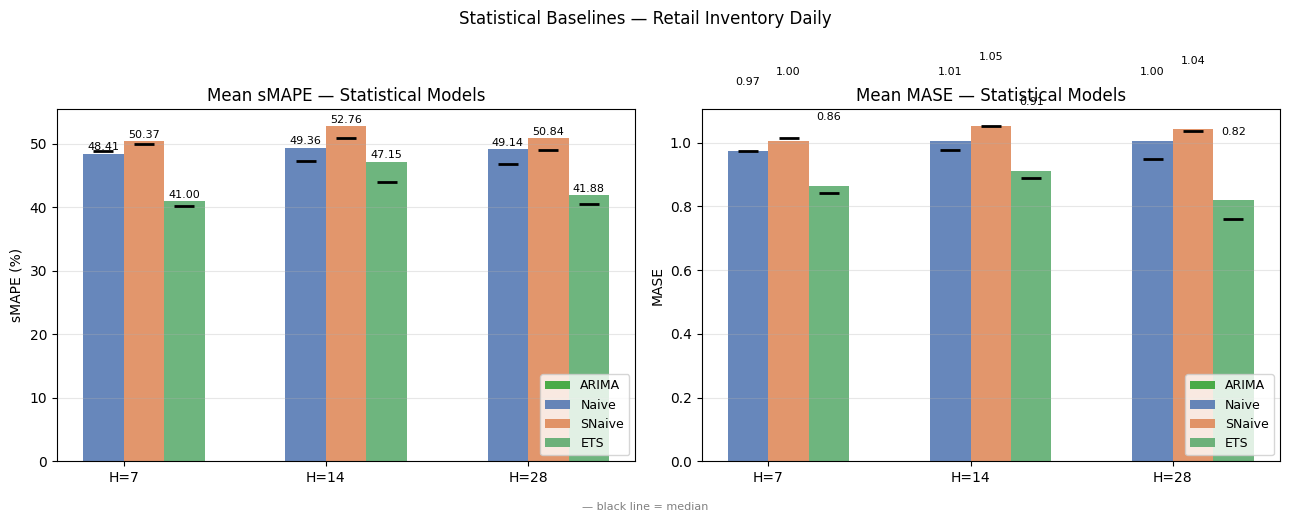

In [8]:

stat_names = ['ARIMA', 'Naive', 'SNaive', 'ETS']

x = np.arange(len(HORIZONS))
width = 0.2

offset = np.array([-1.5, -0.5, 0.5, 1.5]) * width

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


# =========================
# loop metrics
# =========================

for metric, ax, ylabel, title in [

    ('mean_smape', axes[0], 'sMAPE (%)', 'Mean sMAPE — Statistical Models'),

    ('mean_mase', axes[1], 'MASE', 'Mean MASE — Statistical Models'),

]:

    for i, model in enumerate(stat_names):

        vals = []

        for h in HORIZONS:

            df = stat_models[
                (stat_models['model'] == model) &
                (stat_models['horizon'] == h)
            ]

            if len(df) == 0:
                vals.append(np.nan)
            else:
                vals.append(float(df[metric].values[0]))

        bars = ax.bar(
            x + offset[i],
            vals,
            width,
            label=model,
            color=COLORS[model],
            alpha=0.85
        )

        for bar, v in zip(bars, vals):

            if not np.isnan(v):

                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.2,
                    f'{v:.2f}',
                    ha='center',
                    va='bottom',
                    fontsize=8
                )

    ax.set_xticks(x)
    ax.set_xticklabels([f'H={h}' for h in HORIZONS])

    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)


    # ===== median overlay =====

    med_col = metric.replace('mean', 'median')

    for i, model in enumerate(stat_names):

        meds = []

        for h in HORIZONS:

            df = stat_models[
                (stat_models['model'] == model) &
                (stat_models['horizon'] == h)
            ]

            if len(df) == 0:
                meds.append(np.nan)
            else:
                meds.append(float(df[med_col].values[0]))

        ax.scatter(
            x + offset[i],
            meds,
            marker='_',
            s=200,
            color='black',
            zorder=5,
            linewidths=2
        )


plt.figtext(
    0.5,
    -0.02,
    '— black line = median',
    ha='center',
    fontsize=8,
    color='gray'
)

plt.suptitle(
    'Statistical Baselines — Retail Inventory Daily',
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    f'{RESULT_DIR}/plot_stat_models.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## 2. Prophet — MSE / RMSE / MAE

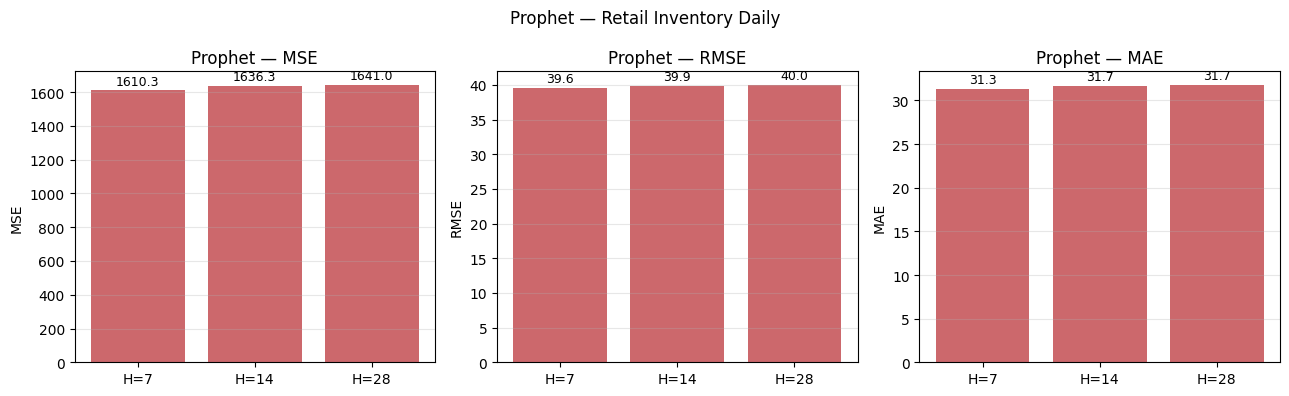

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, metric, ylabel in zip(axes,
    ['mean_mse', 'mean_rmse', 'mean_mae'],
    ['MSE', 'RMSE', 'MAE']):
    vals = [float(prophet[prophet['horizon']==h][metric].values[0]) for h in HORIZONS]
    bars = ax.bar([f'H={h}' for h in HORIZONS], vals, color=COLORS['Prophet'], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(f'Prophet — {ylabel}')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Prophet — Retail Inventory Daily', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/plot_prophet.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Chronos — MASE

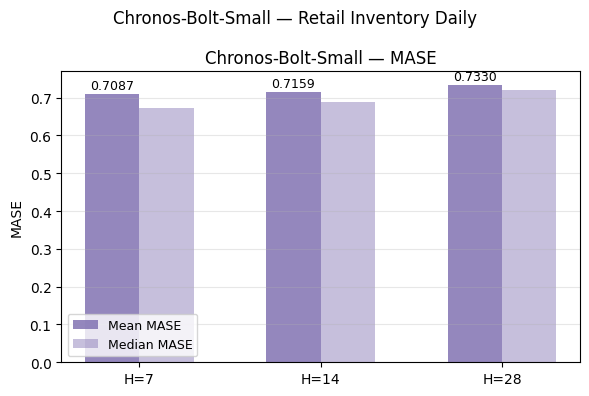

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

mean_vals   = [float(chronos[chronos['horizon']==h]['mean_mase'].values[0])   for h in HORIZONS]
median_vals = [float(chronos[chronos['horizon']==h]['median_mase'].values[0]) for h in HORIZONS]

x = np.arange(len(HORIZONS))
bars = ax.bar(x - 0.15, mean_vals,   0.3, label='Mean MASE',   color=COLORS['Chronos-Bolt-Small'], alpha=0.85)
ax.bar(x + 0.15, median_vals, 0.3, label='Median MASE', color=COLORS['Chronos-Bolt-Small'], alpha=0.45)

for bar, v in zip(bars, mean_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels([f'H={h}' for h in HORIZONS])
ax.set_ylabel('MASE'); ax.set_title('Chronos-Bolt-Small — MASE')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Chronos-Bolt-Small — Retail Inventory Daily', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/plot_chronos.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. MASE Comparison — All Models (shared metric)

In [11]:
# Ranking table — sort by mean_mase per horizon
from IPython.display import display

mase_models = {
    'ARIMA':              arima,
    'Naive':              naive,
    'SNaive':             snaive,
    'ETS':                ets,
    'Chronos-Bolt-Small': chronos,
}

for h in HORIZONS:
    rows = []
    for model, df in mase_models.items():
        row = df[df['horizon'] == h][['mean_mase']].copy()
        row['model'] = model
        rows.append(row)
    sub = pd.concat(rows)[['model', 'mean_mase']].sort_values('mean_mase').reset_index(drop=True)
    sub.index += 1
    sub.columns = ['Model', 'Mean MASE']
    print(f'\n── H={h} ──')
    display(sub)


── H=7 ──


,Model,Mean MASE
1,Chronos-Bolt-Small,0.7087
2,ARIMA,0.7463
3,ETS,0.8637
4,Naive,0.9733
5,SNaive,1.0045



── H=14 ──


,Model,Mean MASE
1,Chronos-Bolt-Small,0.7159
2,ARIMA,0.7477
3,ETS,0.9109
4,Naive,1.0057
5,SNaive,1.0514



── H=28 ──


,Model,Mean MASE
1,Chronos-Bolt-Small,0.7330
2,ARIMA,0.7447
3,ETS,0.8187
4,Naive,1.0045
5,SNaive,1.0414


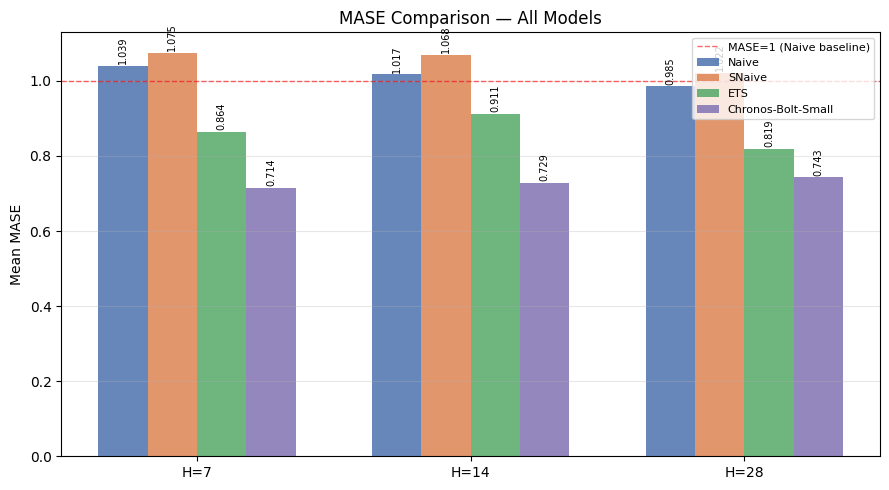

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x      = np.arange(len(HORIZONS))
n      = len(mase_models)
width  = 0.18
offset = np.linspace(-(n-1)/2, (n-1)/2, n) * width

for i, (model, df) in enumerate(mase_models.items()):
    vals = [float(df[df['horizon']==h]['mean_mase'].values[0]) for h in HORIZONS]
    bars = ax.bar(x + offset[i], vals, width, label=model, color=COLORS[model], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.axhline(1.0, color='red', linestyle='--', linewidth=1, alpha=0.6, label='MASE=1 (Naive baseline)')
ax.set_xticks(x); ax.set_xticklabels([f'H={h}' for h in HORIZONS])
ax.set_ylabel('Mean MASE'); ax.set_title('MASE Comparison — All Models')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/plot_mase_comparison.png', dpi=150, bbox_inches='tight')
plt.show()